# Práctica: Desmitificando los LLMs y el Mecanismo de Atención

**Asignatura:** Inteligencia Artificial  
**Carrera:** Ingeniería Mecatrónica  
**Profesora:** Mónica Tahan  
**Referencia:** Vaswani et al., "Attention is All You Need" (2017)

**Objetivo:** Entender matemáticamente y visualizar cómo los modelos de IA procesan el lenguaje y el contexto técnico.

---

## 1. Introducción: ¿Cómo entienden el lenguaje las máquinas?

Las redes neuronales no procesan texto, procesan **números**. Antes de entender la arquitectura Transformer, debemos entender cómo convertimos palabras en vectores numéricos.

A este proceso se le llama **Embedding**. Imaginemos que cada palabra es un punto en un espacio vectorial multidimensional.

In [2]:
import numpy as np # importando numpy para manipulación numérica
import matplotlib.pyplot as plt #para graficar
import seaborn as sns

# Configuración de visualización
np.set_printoptions(precision=3, suppress=True) # para que emplee solo 3 decimales y que evite notaciones científicas
plt.style.use('seaborn-v0_8-darkgrid') #para formatear la grilla de los gráficos

### 1.1 Representación Vectorial (Embeddings Simplificados)

**Explicación del Criterio Numérico:**
En un modelo real (como GPT-4), estos números se aprenden automáticamente durante semanas de entrenamiento. Sin embargo, para este ejercicio didáctico, hemos asignado **valores manuales** siguiendo un criterio semántico para entender qué representan.

Hemos decidido que nuestro universo tiene **4 dimensiones** ($d_{model} = 4$). Cada posición del vector representa una característica:

| Índice | Característica | Significado del Valor (0.0 a 1.0) |
| :--- | :--- | :--- |
| **0** | **Mecánico** | ¿Qué tan relacionado está con máquinas, hardware o física? |
| **1** | **Acción** | ¿Es un verbo o implica movimiento/dinamismo? |
| **2** | **Humano** | ¿Es una persona, profesión o entidad biológica? |
| **3** | **Abstracto** | ¿Es un concepto teórico, inmaterial o de control? |

In [3]:
# Diccionario de embeddings manuales
# Vector = [Mecánico, Acción, Humano, Abstracto]

embeddings = {
    # ROBOT: Alto en Mecánico (0.9), Medio en Acción (0.5), Nulo en Humano (0.0)
    "robot":      np.array([0.9, 0.5, 0.0, 0.1]),
    
    # INGENIERO: Alto en Humano (0.9), Medio en Acción (0.6), Bajo en Mecánico (0.1)
    "ingeniero":  np.array([0.1, 0.6, 0.9, 0.2]),
    
    # REPARA: Muy alto en Acción (0.9), implica un agente humano (0.5) o mecánico
    "repara":     np.array([0.1, 0.9, 0.5, 0.0]),
}

print("Vector de 'robot':", embeddings["robot"])
print("Explicación: [0.9 Mecánico, 0.5 Acción, 0.0 Humano, 0.1 Abstracto]")

Vector de 'robot': [0.9 0.5 0.  0.1]
Explicación: [0.9 Mecánico, 0.5 Acción, 0.0 Humano, 0.1 Abstracto]


## 2. El Mecanismo de Atención (Scaled Dot-Product Attention)

### Eficiencia Matemática
El paper destaca que la atención por producto punto es **más rápida y eficiente en memoria** que otros métodos porque usa multiplicación de matrices altamente optimizada en hardware de GPU.

### La Fórmula Explicada
$$ \text{Attention}(Q, K, V) = \text{softmax}\left(\frac{Q K^T}{\sqrt{d_k}}\right) V $$

1.  **$Q \cdot K^T$ (Producto Punto):** Multiplicamos la consulta (Query) por la clave (Key). En álgebra lineal, el producto punto mide la **similitud**. Si dos vectores apuntan al mismo lado, el valor es alto.
2.  **$/ \sqrt{d_k}$ (Escalado):** Dividimos por la raíz de la dimensión. Esto evita que los números sean gigantescos, lo que "saturaría" a la red neuronal (haciéndola lenta de entrenar).
3.  **Softmax:** Convierte los puntajes brutos en una **probabilidad**. Hace que todos los números sumen 1 (100%). Así sabemos qué porcentaje de atención dar a cada palabra.
4.  **$\cdot V$ (Multiplicación por Valor):** Finalmente, multiplicamos esa probabilidad por el contenido real (Value) para obtener el resumen ponderado.

In [5]:
def softmax(x):
    """Calcula la función Softmax para convertir logits a probabilidades."""
    # Restamos el max para estabilidad numérica (evitar explosión exponencial)
    e_x = np.exp(x - np.max(x)) # e^x para cada elemento, normalizado por la suma de e^x
    return e_x / e_x.sum(axis=-1, keepdims=True) # Normaliza cada fila para que sume 1 (probabilidades)

def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Calcula la atención escalada por producto punto.
    Argumentos:
        Q: Matriz de Consultas (Lo que busco)
        K: Matriz de Claves (Lo que ofrezco)
        V: Matriz de Valores (El contenido)
        mask: Opcional. Matriz para ocultar futuro (poner -infinito).
    """
    # 1. Producto Punto (Q * K^T)
    # Calculamos la similitud entre cada par de palabras.
    matmul_qk = np.dot(Q, K.T) # Producto punto entre Q y la transpuesta de K para obtener similitudes
    print("Producto punto (Q * K^T):\n", matmul_qk)
    
    # 2. Escalar (Scale)
    # d_k es la dimensión de los vectores (4 en nuestro caso)
    d_k = Q.shape[-1] # Obtenemos la dimensión de los vectores (4 en este caso)
    scaled_attention_logits = matmul_qk / np.sqrt(d_k) # Escalamos dividiendo por la raíz cuadrada de la dimensión para evitar valores muy grandes
    print("Logits escalados:\n", scaled_attention_logits)
    
    # 3. Aplicar Máscara (si existe)
    if mask is not None:
        # Donde la máscara es 1, asignamos un número muy negativo (-1e9)
        # Esto hará que al aplicar Softmax, la probabilidad sea CERO.
        scaled_attention_logits += (mask * -1e9) # Aplicamos la máscara para ocultar posiciones futuras (si es necesario)
        print("Logits después de aplicar máscara:\n", scaled_attention_logits)
    
    # 4. Softmax (Obtener pesos de atención)
    # Convierte logits en probabilidades (0.0 a 1.0)
    attention_weights = softmax(scaled_attention_logits) # Aplicamos Softmax para obtener los pesos de atención
    print("Pesos de atención (Softmax):\n", attention_weights)
    
    # 5. Multiplicar por Values
    # Mezcla los significados de las palabras según su importancia
    output = np.dot(attention_weights, V) # Multiplicamos los pesos de atención por los valores para obtener la salida final
    print("Salida de atención (Attention Output):\n", output)
    
    return output, attention_weights

### Ejecución Básica (Sin Máscara)
Usaremos la frase **"Ingeniero repara robot"**.

Matriz de entrada X:
 [[0.1 0.6 0.9 0.2]
 [0.1 0.9 0.5 0. ]
 [0.9 0.5 0.  0.1]]
Producto punto (Q * K^T):
 [[1.22 1.   0.41]
 [1.   1.07 0.54]
 [0.41 0.54 1.07]]
Logits escalados:
 [[0.61  0.5   0.205]
 [0.5   0.535 0.27 ]
 [0.205 0.27  0.535]]
Pesos de atención (Softmax):
 [[0.39  0.35  0.26 ]
 [0.353 0.366 0.281]
 [0.289 0.309 0.402]]
Salida de atención (Attention Output):
 [[0.308 0.679 0.526 0.104]
 [0.325 0.682 0.501 0.099]
 [0.422 0.652 0.415 0.098]]


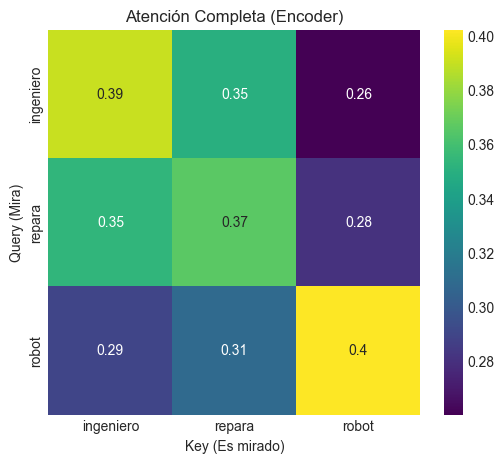

In [6]:
input_words = ["ingeniero", "repara", "robot"]

# Creamos la matriz X apilando los vectores de cada palabra
X = np.array([embeddings[w] for w in input_words]) # Matriz de entrada (3 palabras x 4 dimensiones)
print("Matriz de entrada X:\n", X)

# En Self-Attention (Auto-atención), la misma frase se pregunta a sí misma.
# Por eso Q, K y V son iguales a X.
output, weights = scaled_dot_product_attention(X, X, X)

# Visualizar
plt.figure(figsize=(6, 5))
sns.heatmap(weights, xticklabels=input_words, yticklabels=input_words, annot=True, cmap="viridis")
plt.title("Atención Completa (Encoder)")
plt.ylabel("Query (Mira)")
plt.xlabel("Key (Es mirado)")
plt.show()

## 3. Masked Multi-Head Attention (Atención Enmascarada)

En el **Decodificador** (la parte que genera texto), el modelo no puede ver el futuro. Cuando genera la palabra 2, solo puede ver la palabra 1. No puede ver la 3.

Para lograr esto, aplicamos una **Máscara (Mask)**. Esto preserva la **propiedad auto-regresiva**.

Técnicamente, establecemos a $-\infty$ los valores ilegales antes del Softmax.

Matriz de Máscara (1 = Ocultar/Prohibido):
[[0. 1. 1.]
 [0. 0. 1.]
 [0. 0. 0.]]
Producto punto (Q * K^T):
 [[1.22 1.   0.41]
 [1.   1.07 0.54]
 [0.41 0.54 1.07]]
Logits escalados:
 [[0.61  0.5   0.205]
 [0.5   0.535 0.27 ]
 [0.205 0.27  0.535]]
Logits después de aplicar máscara:
 [[ 6.10e-01 -1.00e+09 -1.00e+09]
 [ 5.00e-01  5.35e-01 -1.00e+09]
 [ 2.05e-01  2.70e-01  5.35e-01]]
Pesos de atención (Softmax):
 [[1.    0.    0.   ]
 [0.491 0.509 0.   ]
 [0.289 0.309 0.402]]
Salida de atención (Attention Output):
 [[0.1   0.6   0.9   0.2  ]
 [0.1   0.753 0.697 0.098]
 [0.422 0.652 0.415 0.098]]


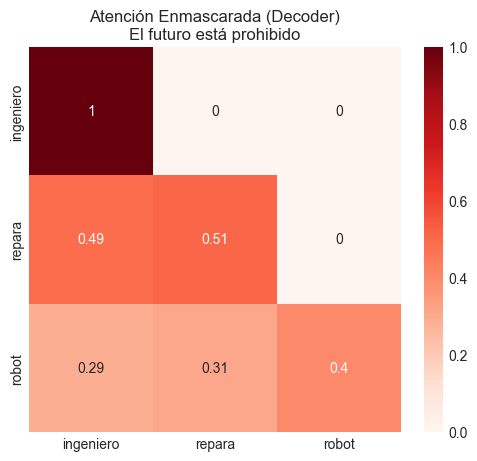

In [7]:
# Crear una máscara triangular superior (Look-ahead mask)
# np.triu(..., k=1) genera un triángulo de 1s arriba de la diagonal.
# Esto significa: "La posición 0 NO puede ver la 1 ni la 2".
seq_len = len(input_words) # longitud de la secuencia (3 en este caso)
look_ahead_mask = np.triu(np.ones((seq_len, seq_len)), k=1) # k=1 para que la diagonal sea 0 y el triángulo superior sea 1

print("Matriz de Máscara (1 = Ocultar/Prohibido):")
print(look_ahead_mask)

# Aplicar atención con máscara
masked_output, masked_weights = scaled_dot_product_attention(X, X, X, mask=look_ahead_mask)

# Visualizar la diferencia
plt.figure(figsize=(6, 5))
sns.heatmap(masked_weights, xticklabels=input_words, yticklabels=input_words, annot=True, cmap="Reds")
plt.title("Atención Enmascarada (Decoder)\nEl futuro está prohibido")
plt.show()

**Observación:** Noten cómo el triágunlo superior es cero. "Ingeniero" solo se mira a sí mismo. "Repara" mira a "Ingeniero" y "Repara". "Robot" puede mirar a todos. Así es como ChatGPT genera texto palabra por palabra.

---

## 4. Multi-Head Attention (Atención Multi-Cabeza)

En lugar de una sola atención gigante, dividimos el cerebro en $h$ cabezas independientes. Esto permite atender a diferentes **subespacios de representación** al mismo tiempo.

*   **Cabeza 1:** Podría enfocarse en **quién** hace la acción (Sujeto) - Dimensiones 0 y 1.
*   **Cabeza 2:** Podría enfocarse en **cuándo** ocurre o conceptos abstractos - Dimensiones 2 y 3.

Si $d_{model} = 4$ y usamos $h=2$ cabezas:
*   $d_k = d_v = 4 / 2 = 2$.

Vector original 'Ingeniero': [0.1 0.6 0.9 0.2]
Header 1 (Física/Acción): [0.1 0.6]
Header 2 (Humana/Conceptos): [0.9 0.2]
Producto punto (Q * K^T):
 [[0.37 0.55 0.39]
 [0.55 0.82 0.54]
 [0.39 0.54 1.06]]
Logits escalados:
 [[0.262 0.389 0.276]
 [0.389 0.58  0.382]
 [0.276 0.382 0.75 ]]
Pesos de atención (Softmax):
 [[0.317 0.361 0.322]
 [0.312 0.378 0.31 ]
 [0.269 0.299 0.432]]
Salida de atención (Attention Output):
 [[0.358 0.676]
 [0.348 0.682]
 [0.446 0.647]]
Producto punto (Q * K^T):
 [[0.85 0.45 0.02]
 [0.45 0.25 0.  ]
 [0.02 0.   0.01]]
Logits escalados:
 [[0.601 0.318 0.014]
 [0.318 0.177 0.   ]
 [0.014 0.    0.007]]
Pesos de atención (Softmax):
 [[0.433 0.326 0.241]
 [0.385 0.334 0.28 ]
 [0.336 0.331 0.333]]
Salida de atención (Attention Output):
 [[0.553 0.111]
 [0.514 0.105]
 [0.468 0.1  ]]


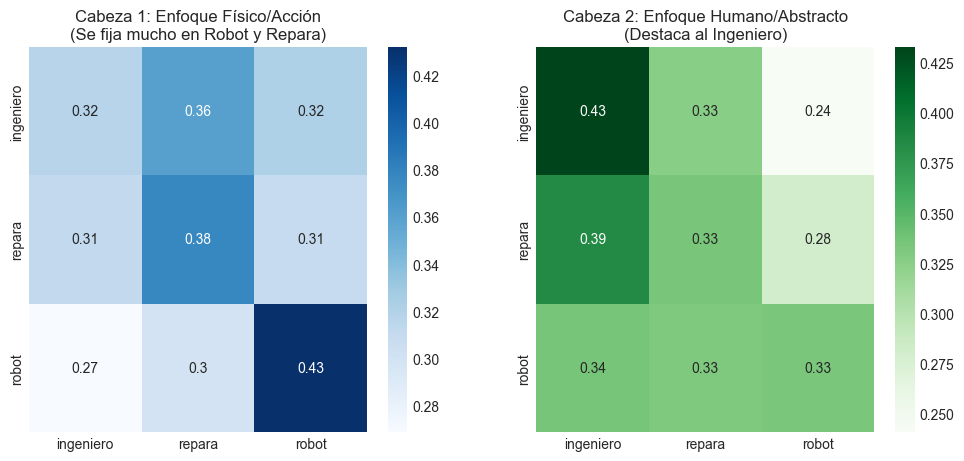

In [8]:
# Dividimos nuestros vectores de 4 dimensiones en 2 cabezas de 2 dimensiones
h = 2 # número de headers
dk = 2 # dimensión de cada header (4 dimensiones totales / 2 cabezas = 2 dimensiones por header)

# Header 1: Toma las columnas 0 y 1 (Mecánico, Acción)
head1_X = X[:, 0:2]

# Header 2: Toma las columnas 2 y 3 (Humano, Abstracto)
head2_X = X[:, 2:4]

print(f"Vector original 'Ingeniero': {X[0]}") # El vector completo de "ingeniero"
print(f"Header 1 (Física/Acción): {head1_X[0]}") # El vector de "ingeniero" en el header 1 (Mecánico, Acción)
print(f"Header 2 (Humana/Conceptos): {head2_X[0]}") # El vector de "ingeniero" en el header 2 (Humano, Abstracto)

# Ejecutamos Atención INDEPENDIENTE en cada cabeza
out1, w1 = scaled_dot_product_attention(head1_X, head1_X, head1_X) # Atención en la header 1 (Mecánico/Acción)
out2, w2 = scaled_dot_product_attention(head2_X, head2_X, head2_X) # Atención en la header 2 (Humano/Abstracto)

# Visualizamos las dos "perspectivas" del modelo
fig, ax = plt.subplots(1, 2, figsize=(12, 5)) # Creamos una figura con 1 fila y 2 columnas para mostrar ambos mapas de calor lado a lado

sns.heatmap(w1, xticklabels=input_words, yticklabels=input_words, annot=True, cmap="Blues", ax=ax[0]) # Mapa de calor para la header 1 (Mecánico/Acción)
ax[0].set_title("Cabeza 1: Enfoque Físico/Acción\n(Se fija mucho en Robot y Repara)") # El modelo se enfoca en la relación mecánica y de acción entre las palabras

sns.heatmap(w2, xticklabels=input_words, yticklabels=input_words, annot=True, cmap="Greens", ax=ax[1]) # Mapa de calor para la header 2 (Humano/Abstracto)
ax[1].set_title("Cabeza 2: Enfoque Humano/Abstracto\n(Destaca al Ingeniero)") # El modelo se enfoca en la relación humana y conceptual, destacando al ingeniero

plt.show()

## 5. Aplicación NLP Real: Visualizando BERT

Ya entendemos la matemática. Ahora vamos a usar un modelo real (**BERT**) usando la librería `transformers` para ver cómo analiza una frase técnica compleja.

**Frase:** "Válvula abierta por presión excesiva."

*Nota: `bert-base-multilingual-cased` es un modelo entrenado por Google con millones de frases en 104 idiomas.*

C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 544.18it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bia

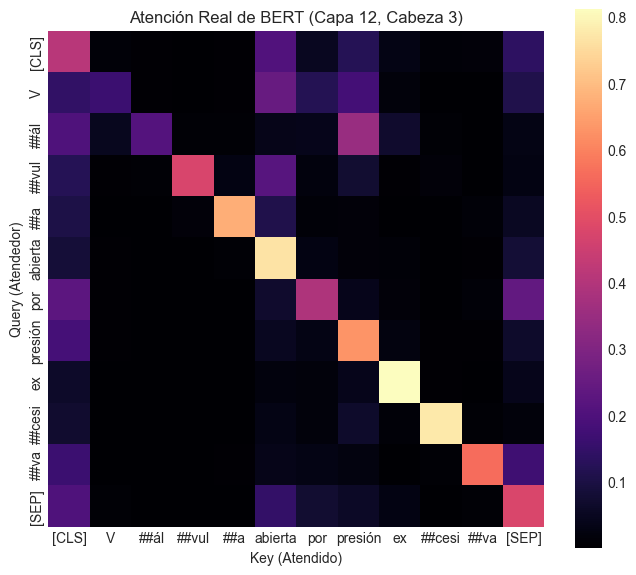

Interpretación: Los colores brillantes indican qué palabras están 'conectadas' en la mente de la IA.


In [9]:
# Instalación necesaria del ecosistema HuggingFace
try:
    from transformers import BertTokenizer, BertModel
    import torch # PyTorch es la biblioteca de IA que usa HuggingFace para manejar tensores y modelos
except ImportError:
    print("Necesitas instalar 'transformers' y 'torch' para esta sección.")
    print("!pip install transformers torch")
    
# Cargamos el Tokenizer (divide texto en palabras/tokens)
# y el Modelo (contiene los pesos neuronales).
try:
    model_name = 'bert-base-multilingual-cased'
    tokenizer = BertTokenizer.from_pretrained(model_name)
    # output_attentions=True es CRUCIAL: le pide al modelo que nos devuelva las matrices internas
    model = BertModel.from_pretrained(model_name, output_attentions=True)
    
    text = "Válvula abierta por presión excesiva"
    # Tokenizamos: Convierte "Válvula" en números IDs que el modelo entiende
    #Toma el texto, lo divide en tokens, los convierte a IDs numéricos y arma un diccionario con tensores de PyTorch ('pt'). 
    # Además agrega tokens especiales como [CLS] y [SEP] que BERT necesita

    inputs = tokenizer(text, return_tensors="pt", add_special_tokens=True)

    #inputs = tokenizer.encode_plus(text, return_tensors='pt', add_special_tokens=True) # usería la función encode_plus, pero el método tokenizer(...) es más directo y recomendado en las últimas versiones de HuggingFace.
    #Toma la secuencia de IDs que quedó en inputs['input_ids'][0] y la convierte de vuelta a los tokens 
    # (sub-palabras) en formato texto para poder verlos o graficarlos
    #tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0]) # este método es correcto, pero lo reemplacé por el siguiente para mantener consistencia con la sintaxis del tokenizer(...)
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    # Inferencia: Pasamos los números por las 12 capas de neuronas que es el valor base de BERT
    outputs = model(**inputs) # El modelo procesa la entrada y devuelve varias cosas, incluyendo las atenciones internas
    
    # Obtenemos las atenciones. Es una lista de 12 tensores (uno por capa).
    attention = outputs.attentions # Cada elemento de esta lista es un tensor de forma (batch_size, num_heads, seq_len, seq_len) que contiene las matrices de atención para cada header en esa capa.
    
    # Configuración de visualización
    layer_to_view = -1  # Última capa (Capa 12), suele tener las relaciones más semánticas
    head_to_view = 3    # Cabeza 3 (arbitraria, BERT tiene 12 cabezas)
    
    # Extraemos la matriz y quitamos gradientes (detach) para poder graficarla
    att_matrix = attention[layer_to_view][0, head_to_view].detach().numpy() # Seleccionamos la capa y el header específica, y convertimos a numpy para graficar

    plt.figure(figsize=(8, 7))
    sns.heatmap(att_matrix, xticklabels=tokens, yticklabels=tokens, 
                cmap="magma", square=True, annot=False)
    plt.title(f"Atención Real de BERT (Capa {12+layer_to_view+1}, Cabeza {head_to_view})")
    plt.xlabel("Key (Atendido)")
    plt.ylabel("Query (Atendedor)")
    plt.show()
    
    print("Interpretación: Los colores brillantes indican qué palabras están 'conectadas' en la mente de la IA.")

except Exception as e:
    print(f"Nota: Si ves un error de conexión, es porque la primera vez necesita internet para bajar el modelo (500MB). Error: {e}")